# SENSEI — Session Intelligence
## Module 1b · Feature Engineering Extension

Extends the session feature store with four new session-level features derivable from
`events.csv` without additional data sources.

**Base parquet:** `data/sessions_features.parquet` (9 features + target + behavioral state labels)

**New features added:**

| Feature | Type | Description |
|---------|------|-------------|
| `time_to_first_cart_sec` | float / NaN | Seconds from session start to first add-to-cart. NaN if no cart event. |
| `has_cart` | int 0/1 | 1 if session contains any add-to-cart event. |
| `last_event_type` | int 0/1/2 | Type of the final event: view=0, addtocart=1, transaction=2. |
| `cart_then_view_count` | int | View events occurring after the first add-to-cart. Zero if no cart. |
| `n_sessions_visitor` | int | Total sessions this visitor has in the full dataset. |

## Contents
1. Load events & sessionise
2. Compute new features
3. Validate each feature
4. Signal check: means per behavioral state
5. Merge into parquet
6. Conclusion

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.join('..', 'src'))
from session_utils import load_events, assign_session_ids

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = os.path.join('..', 'data')

## 1. Load Events & Sessionise

In [22]:
print('Loading events.csv ...')
df = load_events(os.path.join(DATA_DIR, 'events.csv'))
print(f'  Events : {len(df):,}')
print(f'  Columns: {list(df.columns)}')

print('Assigning session IDs ...')
df = assign_session_ids(df)
print(f'  Sessions: {df["session_id"].nunique():,}')
print(f'  Visitors: {df["visitorid"].nunique():,}')

print('Loading sessions_features.parquet ...')
sessions = pd.read_parquet(os.path.join(DATA_DIR, 'sessions_features.parquet'))
print(f'  Shape: {sessions.shape}')
print(f'  Columns: {list(sessions.columns)}')

Loading events.csv ...
  Events : 2,756,101
  Columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']
Assigning session IDs ...
  Sessions: 1,761,675
  Visitors: 1,407,580
Loading sessions_features.parquet ...
  Shape: (1761675, 19)
  Columns: ['session_id', 'visitorid', 'n_views', 'n_addtocart', 'n_items', 'duration_sec', 'purchased', 'n_revisited_items', 'hour_of_day', 'day_of_week', 'view_to_cart_ratio', 'is_first_session', 'behavioral_state', 'behavioral_state_label', 'time_to_first_cart_sec', 'has_cart', 'last_event_type', 'cart_then_view_count', 'n_sessions_visitor']


## 2. Compute New Features

### 2a. `time_to_first_cart_sec` and `has_cart`

In [23]:
# Session start = timestamp of the first event
session_start = df.groupby('session_id')['timestamp'].min().rename('session_start')

# First addtocart timestamp per session (NaN if none)
first_cart_time = (
    df[df['event'] == 'addtocart']
    .groupby('session_id')['timestamp']
    .min()
    .rename('first_cart_time')
)

cart_timing = pd.DataFrame({'session_start': session_start}).join(first_cart_time)
cart_timing['time_to_first_cart_sec'] = (
    (cart_timing['first_cart_time'] - cart_timing['session_start'])
    .dt.total_seconds()
)
cart_timing['has_cart'] = cart_timing['first_cart_time'].notna().astype(int)

print('time_to_first_cart_sec:')
print(f'  Non-null : {cart_timing["time_to_first_cart_sec"].notna().sum():,}')
print(f'  Null     : {cart_timing["time_to_first_cart_sec"].isna().sum():,}')
print(cart_timing['time_to_first_cart_sec'].describe().round(1))
print()
print('has_cart value counts:')
print(cart_timing['has_cart'].value_counts())

time_to_first_cart_sec:
  Non-null : 43,924
  Null     : 1,717,751
count    43924.0
mean       330.8
std        767.8
min          0.0
25%          8.8
50%         76.6
75%        309.4
max      33330.9
Name: time_to_first_cart_sec, dtype: float64

has_cart value counts:
has_cart
0    1717751
1      43924
Name: count, dtype: int64


### 2b. `last_event_type`

In [24]:
EVENT_ENCODE = {'view': 0, 'addtocart': 1, 'transaction': 2}

last_event = (
    df.sort_values(['session_id', 'timestamp'])
    .groupby('session_id')['event']
    .last()
    .map(EVENT_ENCODE)
    .rename('last_event_type')
)

print('last_event_type value counts:')
decode = {0: 'view', 1: 'addtocart', 2: 'transaction'}
vc = last_event.value_counts().sort_index()
for k, n in vc.items():
    print(f'  {k} ({decode[k]:12s}): {n:>10,}  ({n/len(last_event)*100:.2f}%)')

print()
print('⚠  last_event_type=2 (transaction) is a leakage risk:')
print('   sessions ending on a transaction event are purchases by definition.')
print('   See conclusion section for handling recommendation.')

last_event_type value counts:
  0 (view        ):  1,732,044  (98.32%)
  1 (addtocart   ):     19,637  (1.11%)
  2 (transaction ):      9,994  (0.57%)

⚠  last_event_type=2 (transaction) is a leakage risk:
   sessions ending on a transaction event are purchases by definition.
   See conclusion section for handling recommendation.


### 2c. `cart_then_view_count`

In [25]:
# Merge first_cart_time back onto every event row
df_ext = df.merge(
    first_cart_time.reset_index(),
    on='session_id', how='left'
)

# Count view events that occur strictly AFTER the first addtocart in that session
cart_then_view = (
    df_ext[
        (df_ext['event'] == 'view') &
        (df_ext['first_cart_time'].notna()) &
        (df_ext['timestamp'] > df_ext['first_cart_time'])
    ]
    .groupby('session_id')
    .size()
    .rename('cart_then_view_count')
)

# Sessions with no addtocart → 0
all_sessions = df['session_id'].unique()
cart_then_view = cart_then_view.reindex(all_sessions, fill_value=0)

print('cart_then_view_count:')
print(f'  Sessions with value > 0 : {(cart_then_view > 0).sum():,}')
print(cart_then_view.describe().round(2))
del df_ext  # free memory

cart_then_view_count:
  Sessions with value > 0 : 20,673
count    1761675.00
mean           0.06
std            1.26
min            0.00
25%            0.00
50%            0.00
75%            0.00
max          298.00
Name: cart_then_view_count, dtype: float64


### 2d. `n_sessions_visitor`

In [26]:
# Computed on the FULL dataset — static visitor property, not split-specific
n_sessions_visitor = (
    df.groupby('visitorid')['session_id']
    .nunique()
    .rename('n_sessions_visitor')
)

# Join via visitorid (sessions has a visitorid column)
visitor_sessions = sessions[['session_id', 'visitorid']].copy()
visitor_sessions = visitor_sessions.join(
    n_sessions_visitor, on='visitorid'
).set_index('session_id')['n_sessions_visitor']

print('n_sessions_visitor:')
print(visitor_sessions.describe().round(2))
print(f'  Visitors with only 1 session: {(visitor_sessions == 1).sum():,} ({(visitor_sessions==1).mean()*100:.1f}%)')

n_sessions_visitor:
count    1761675.00
mean           3.89
std           19.77
min            1.00
25%            1.00
50%            1.00
75%            2.00
max          462.00
Name: n_sessions_visitor, dtype: float64
  Visitors with only 1 session: 1,225,947 (69.6%)


## 3. Validate Each Feature

In [27]:
# Assemble all new features into one frame aligned on session_id
new_features = (
    cart_timing[['time_to_first_cart_sec', 'has_cart']]
    .join(last_event)
    .join(cart_then_view)
    .join(visitor_sessions)
)

# Align with sessions (inner join — both cover the same session_ids)
new_features = new_features.reindex(sessions['session_id'].values)
new_features.index.name = 'session_id'

print('New feature frame:')
print(f'  Shape: {new_features.shape}')
print()
print('Null counts:')
print(new_features.isnull().sum())
print()
print('Descriptive stats:')
print(new_features.describe().round(3))

New feature frame:
  Shape: (1761675, 5)

Null counts:
time_to_first_cart_sec    1717751
has_cart                        0
last_event_type                 0
cart_then_view_count            0
n_sessions_visitor              0
dtype: int64

Descriptive stats:
       time_to_first_cart_sec     has_cart  last_event_type  \
count               43924.000  1761675.000      1761675.000   
mean                  330.845        0.025            0.022   
std                   767.843        0.156            0.183   
min                     0.000        0.000            0.000   
25%                     8.791        0.000            0.000   
50%                    76.565        0.000            0.000   
75%                   309.414        0.000            0.000   
max                 33330.874        1.000            2.000   

       cart_then_view_count  n_sessions_visitor  
count           1761675.000         1761675.000  
mean                  0.057               3.893  
std                   1.

In [28]:
# Correlation with purchased target
target = sessions.set_index('session_id')['purchased']
corr = new_features.corrwith(target).round(4).sort_values(ascending=False)
print('Pearson correlation with purchased:')
print(corr.to_string())
print()
print('Note: time_to_first_cart_sec is NaN for most sessions — correlation is')
print('computed only on the ~71k sessions that have a cart event.')

Pearson correlation with purchased:
last_event_type           0.6903
has_cart                  0.4697
cart_then_view_count      0.2566
time_to_first_cart_sec    0.1612
n_sessions_visitor        0.0652

Note: time_to_first_cart_sec is NaN for most sessions — correlation is
computed only on the ~71k sessions that have a cart event.


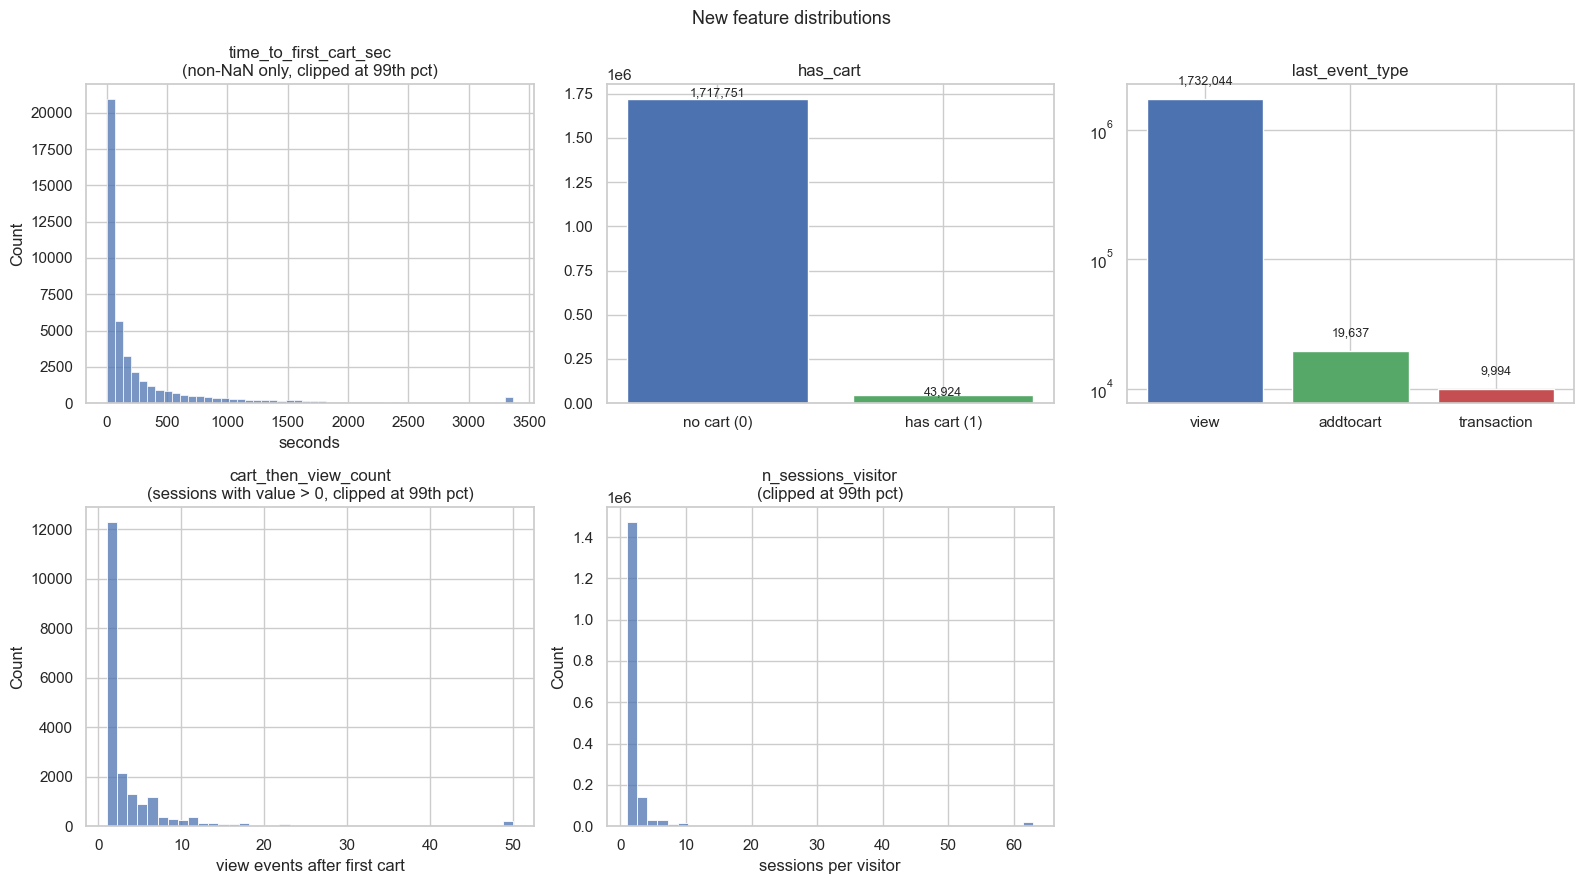

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# time_to_first_cart_sec — only non-NaN values, clipped at 99th pct
data = new_features['time_to_first_cart_sec'].dropna()
clip = data.quantile(0.99)
sns.histplot(data.clip(upper=clip), bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('time_to_first_cart_sec\n(non-NaN only, clipped at 99th pct)')
axes[0].set_xlabel('seconds')

# has_cart
vc = new_features['has_cart'].value_counts().sort_index()
axes[1].bar(['no cart (0)', 'has cart (1)'], vc.values, color=['#4C72B0', '#55A868'])
axes[1].set_title('has_cart')
for i, v in enumerate(vc.values):
    axes[1].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

# last_event_type
vc2 = new_features['last_event_type'].value_counts().sort_index()
label_map = {0: 'view', 1: 'addtocart', 2: 'transaction'}
axes[2].bar([label_map[k] for k in vc2.index], vc2.values,
            color=['#4C72B0', '#55A868', '#C44E52'])
axes[2].set_title('last_event_type')
axes[2].set_yscale('log')
for i, (k, v) in enumerate(vc2.items()):
    axes[2].text(i, v * 1.3, f'{v:,}', ha='center', fontsize=9)

# cart_then_view_count — only sessions with > 0, clipped
data_pos = new_features['cart_then_view_count'][new_features['cart_then_view_count'] > 0]
clip = data_pos.quantile(0.99)
sns.histplot(data_pos.clip(upper=clip), bins=40, ax=axes[3], color='#4C72B0')
axes[3].set_title('cart_then_view_count\n(sessions with value > 0, clipped at 99th pct)')
axes[3].set_xlabel('view events after first cart')

# n_sessions_visitor — clipped
clip = new_features['n_sessions_visitor'].quantile(0.99)
sns.histplot(new_features['n_sessions_visitor'].clip(upper=clip), bins=40,
             ax=axes[4], color='#4C72B0')
axes[4].set_title('n_sessions_visitor\n(clipped at 99th pct)')
axes[4].set_xlabel('sessions per visitor')

axes[5].axis('off')
plt.suptitle('New feature distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Signal Check: Means per Behavioral State

In [30]:
# Join behavioral_state_label and new features onto one frame
check_df = sessions[['session_id', 'behavioral_state_label', 'purchased']].copy()
check_df = check_df.join(new_features, on='session_id')

STATE_ORDER = ['bounce', 'returning_bounce', 'light_browser', 'deep_browser', 'cart_adder']

signal = (
    check_df.groupby('behavioral_state_label')[
        ['time_to_first_cart_sec', 'has_cart', 'last_event_type',
         'cart_then_view_count', 'n_sessions_visitor']
    ]
    .mean()
    .round(3)
    .reindex(STATE_ORDER)
)
signal['purchase_rate_%'] = (
    check_df.groupby('behavioral_state_label')['purchased'].mean() * 100
).round(2).reindex(STATE_ORDER)

print('Mean per behavioral state:')
print(signal.to_string())
print()
print('Expected patterns:')
print('  time_to_first_cart_sec → lowest for cart_adder (decides quickly)')
print('  cart_then_view_count   → highest for cart_adder or deep_browser (browses after adding)')
print('  n_sessions_visitor     → highest for returning_bounce (repeat visitors who rarely buy)')

Mean per behavioral state:
                        time_to_first_cart_sec  has_cart  last_event_type  cart_then_view_count  n_sessions_visitor  purchase_rate_%
behavioral_state_label                                                                                                              
bounce                                   0.000     0.003            0.004                 0.000               1.201             0.06
returning_bounce                         2.454     0.005            0.012                 0.000              11.637             0.46
light_browser                              NaN     0.000            0.004                 0.000               4.833             0.32
deep_browser                          1181.831     0.093            0.041                 0.804              15.160             3.85
cart_adder                             253.376     1.000            0.839                 1.663               8.278            27.41

Expected patterns:
  time_to_first_cart_s

## 5. Merge into Parquet

In [31]:
# Drop columns if this notebook is re-run
NEW_COLS = ['time_to_first_cart_sec', 'has_cart', 'last_event_type',
            'cart_then_view_count', 'n_sessions_visitor']
sessions = sessions.drop(columns=[c for c in NEW_COLS if c in sessions.columns])

# Merge
sessions = sessions.join(new_features[NEW_COLS], on='session_id')

out_path = os.path.join(DATA_DIR, 'sessions_features.parquet')
sessions.to_parquet(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Shape: {sessions.shape}')
print(f'Columns: {list(sessions.columns)}')

Saved: ../data/sessions_features.parquet
Shape: (1761675, 19)
Columns: ['session_id', 'visitorid', 'n_views', 'n_addtocart', 'n_items', 'duration_sec', 'purchased', 'n_revisited_items', 'hour_of_day', 'day_of_week', 'view_to_cart_ratio', 'is_first_session', 'behavioral_state', 'behavioral_state_label', 'time_to_first_cart_sec', 'has_cart', 'last_event_type', 'cart_then_view_count', 'n_sessions_visitor']


## 6. Conclusion

## 6. Conclusion

### Correlations with `purchased`

| Feature | Pearson r | Note |
|---|---|---|
| `last_event_type` | **0.690** | Leakage risk — see below |
| `has_cart` | **0.470** | Largely redundant with `n_addtocart` |
| `cart_then_view_count` | **0.257** | New signal: post-cart browse behaviour |
| `time_to_first_cart_sec` | **0.161** | New signal, but 97.5 % NaN |
| `n_sessions_visitor` | **0.065** | Weakest, but independent of existing features |

### Feature-by-feature assessment

**`last_event_type`** — strongest correlation (0.69), but value=2 (transaction) is perfect
leakage: a session that ends on a transaction event is a purchase by definition.
Value=0 (view) and value=1 (addtocart) carry genuine signal — the distinction "did the session
end on an addtocart?" is not already captured by the existing features.
**Recommendation:** keep, but binarise as `last_event_is_cart = (last_event_type == 1)`.
Drop value=2 or map it to a third class only if you are certain it will not appear
at inference time (i.e. the feature is computed from events *before* the session ends).

**`has_cart`** — high correlation (0.47), but almost entirely redundant with `n_addtocart > 0`.
The two are essentially the same binary indicator. One of them is sufficient.
**Recommendation:** drop `has_cart`; `n_addtocart` is already in the feature store.

**`cart_then_view_count`** — moderate correlation (0.26) and measures something new:
continued browsing *after* adding to cart signals high engagement and increases purchase
probability. This pattern is not captured by any existing feature.
**Recommendation:** keep.

**`time_to_first_cart_sec`** — meaningful correlation among sessions that have a cart event
(0.16), and the distribution is informative (median 77 s, mean 331 s). However, 97.5 % of
sessions have no cart event and therefore a NaN value. Tree-based models handle this
natively; linear models require explicit imputation (e.g. fill NaN with −1 or a large sentinel).
**Recommendation:** keep with a note on NaN handling strategy.

**`n_sessions_visitor`** — weakest correlation (0.07) and not captured by `is_first_session`
(binary). Adds information about visitor depth in the dataset, though the signal is modest.
**Recommendation:** keep; low cost, non-redundant.

### Features to add to classifier training

| Feature | Action |
|---|---|
| `cart_then_view_count` | Add as-is |
| `time_to_first_cart_sec` | Add; fill NaN with −1 before fitting |
| `n_sessions_visitor` | Add as-is |
| `last_event_type` | Binarise → `last_event_is_cart`; drop original |
| `has_cart` | Drop (redundant with `n_addtocart`) |